<a href="https://colab.research.google.com/github/rtgsgara/clabtrial-tokihub/blob/feature-toki/BELKA_TOKIUB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BELKA: Predicting Protein-Molecule Binding with a Balanced Subset**¶
This notebook outlines a complete machine learning workflow to tackle the BELKA protein binding prediction problem. The key strategy here is to handle the massive dataset by first creating a smaller, balanced subset of the data to ensure the model learns from both positive and negative examples equally.

The pipeline is as follows:

1. **Data Analysis**: Analyze the full dataset's target distribution without loading it all into memory.
2. **Subset Creation**: Build a balanced subset with an equal number of binding and non-binding examples.
3. **Data Cleaning & EDA**: Perform exploratory data analysis and clean the subset by removing duplicates.
4. **Preprocessing**: Convert categorical features into a numerical format using one-hot encoding.
5. **Modeling**: Train a Logistic Regression model and evaluate its performance.
6. **Inference**: Make predictions on a sample of the test data.

**Step 1: Analyzing the Target Distribution of the Full Dataset**

Before we do anything else, it's crucial to understand the class distribution in the original, massive dataset. Since the train.csv file is too large to load into memory, we will read it in manageable chunks. By iterating through each chunk and summing the value counts of our target column (binds), we can get a complete picture of the class imbalance across all ~295 million rows.

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving part_1.csv to part_1 (1).csv


In [ ]:
# Path to the large train.csv file
df=pd.read_csv('part_1.csv')


In [ ]:
df.head(5)

,id,buildingblock1_smiles,buildingblock2_smiles,buildingblock3_smiles,molecule_smiles,protein_name,binds
0,0,C#CC[C@@H](CC(=O)O)NC(=O)OCC1c2ccccc2-c2ccccc21,C#CCOc1ccc(CN)cc1.Cl,Br.Br.NCC1CCCN1c1cccnn1,C#CCOc1ccc(CNc2nc(NCC3CCCN3c3cccnn3)nc(N[C@@H]...,BRD4,0
1,1,C#CC[C@@H](CC(=O)O)NC(=O)OCC1c2ccccc2-c2ccccc21,C#CCOc1ccc(CN)cc1.Cl,Br.Br.NCC1CCCN1c1cccnn1,C#CCOc1ccc(CNc2nc(NCC3CCCN3c3cccnn3)nc(N[C@@H]...,HSA,0
2,2,C#CC[C@@H](CC(=O)O)NC(=O)OCC1c2ccccc2-c2ccccc21,C#CCOc1ccc(CN)cc1.Cl,Br.Br.NCC1CCCN1c1cccnn1,C#CCOc1ccc(CNc2nc(NCC3CCCN3c3cccnn3)nc(N[C@@H]...,sEH,0
3,3,C#CC[C@@H](CC(=O)O)NC(=O)OCC1c2ccccc2-c2ccccc21,C#CCOc1ccc(CN)cc1.Cl,Br.NCc1cccc(Br)n1,C#CCOc1ccc(CNc2nc(NCc3cccc(Br)n3)nc(N[C@@H](CC...,BRD4,0
4,4,C#CC[C@@H](CC(=O)O)NC(=O)OCC1c2ccccc2-c2ccccc21,C#CCOc1ccc(CN)cc1.Cl,Br.NCc1cccc(Br)n1,C#CCOc1ccc(CNc2nc(NCc3cccc(Br)n3)nc(N[C@@H](CC...,HSA,0


In [ ]:
df.shape

(298263, 7)

In [ ]:
df.dtypes

,0
id,int64
buildingblock1_smiles,object
buildingblock2_smiles,object
buildingblock3_smiles,object
molecule_smiles,object
protein_name,object
binds,int64


In [ ]:
df.describe()

,id,binds
count,298263.000000,298263.000000
mean,149155.481883,0.002163
std,86141.455677,0.046453
min,0.000000,0.000000
25%,74565.500000,0.000000
50%,149131.000000,0.000000
75%,223696.500000,0.000000
max,298722.000000,1.000000


In [ ]:
df.columns


Index(['id', 'buildingblock1_smiles', 'buildingblock2_smiles',
       'buildingblock3_smiles', 'molecule_smiles', 'protein_name', 'binds',
       'molecule_length'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
id,0
buildingblock1_smiles,0
buildingblock2_smiles,0
buildingblock3_smiles,0
molecule_smiles,0
protein_name,0
binds,0


In [ ]:
binds_counts = df["binds"].value_counts()
print(binds_counts)

binds
0    297618
1       645
Name: count, dtype: int64


In [ ]:
df["molecule_length"] = df["molecule_smiles"]
print(df["molecule_length"].describe())

count    298263.000000
mean      49710.269819
std       28700.757033
min           0.000000
25%       24855.000000
50%       49710.000000
75%       74566.000000
max       99421.000000
Name: molecule_length, dtype: float64


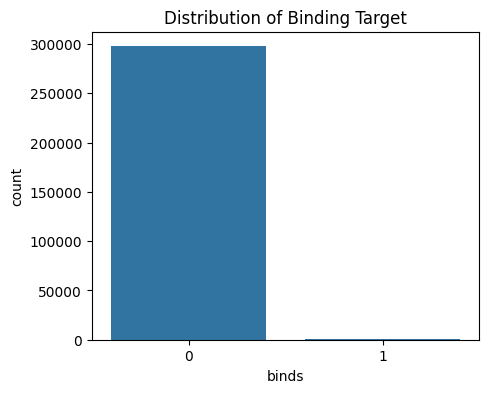

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='binds', data=df)
plt.title('Distribution of Binding Target')
plt.show()


 Molecule Length Stats:
 count    298263.000000
mean      49710.269819
std       28700.757033
min           0.000000
25%       24855.000000
50%       49710.000000
75%       74566.000000
max       99421.000000
Name: molecule_length, dtype: float64


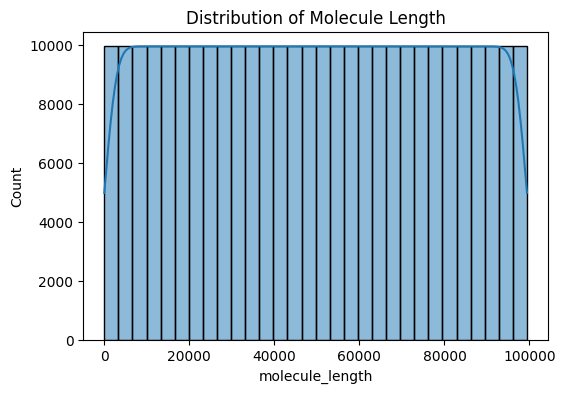

In [ ]:
print("\n Molecule Length Stats:\n", df['molecule_length'].describe())

plt.figure(figsize=(6,4))
sns.histplot(df['molecule_length'], bins=30, kde=True)
plt.title('Distribution of Molecule Length')
plt.show()

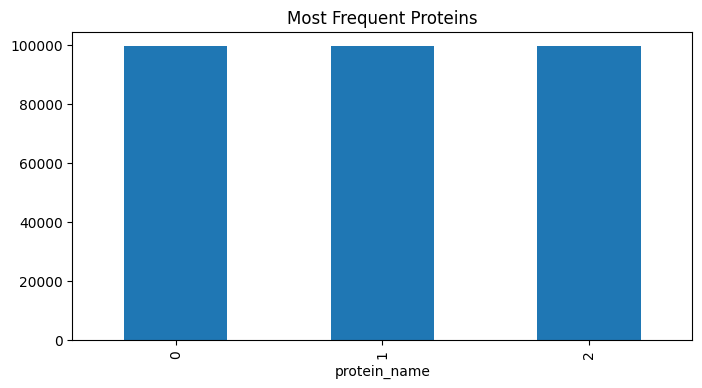

In [ ]:
plt.figure(figsize=(8,4))
df['protein_name'].value_counts().head(10).plot(kind='bar')
plt.title('Most Frequent Proteins')
plt.show()



In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\n📊 Numerical Columns:", num_cols)
print("🔤 Categorical Columns:", cat_cols)


📊 Numerical Columns: ['id', 'buildingblock1_smiles', 'buildingblock2_smiles', 'buildingblock3_smiles', 'molecule_smiles', 'protein_name', 'binds', 'molecule_length']
🔤 Categorical Columns: []


In [ ]:
print("\n NUMERICAL STATS:\n", df[num_cols].describe())
print("\n CATEGORICAL VALUE COUNTS:")
for col in cat_cols:
    print(f"\n{col}:\n", df[col].value_counts())



 NUMERICAL STATS:
                   id  buildingblock1_smiles  buildingblock2_smiles  \
count  298263.000000               298263.0          298263.000000   
mean   149155.481883                    0.0              92.832219   
std     86141.455677                    0.0              54.180890   
min         0.000000                    0.0               0.000000   
25%     74565.500000                    0.0              47.000000   
50%    149131.000000                    0.0              93.000000   
75%    223696.500000                    0.0             140.000000   
max    298722.000000                    0.0             188.000000   

       buildingblock3_smiles  molecule_smiles   protein_name          binds  \
count          298263.000000    298263.000000  298263.000000  298263.000000   
mean              440.871902     49710.269819       0.999993       0.002163   
std               253.462665     28700.757033       0.816498       0.046453   
min                 0.000000     

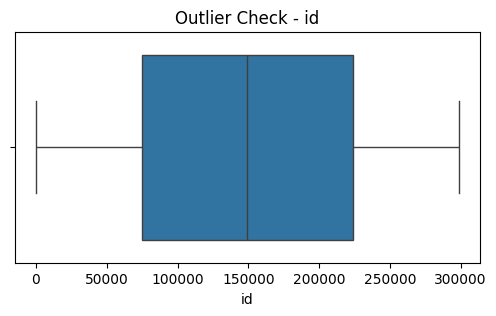

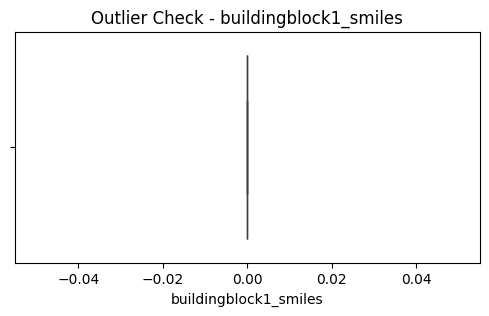

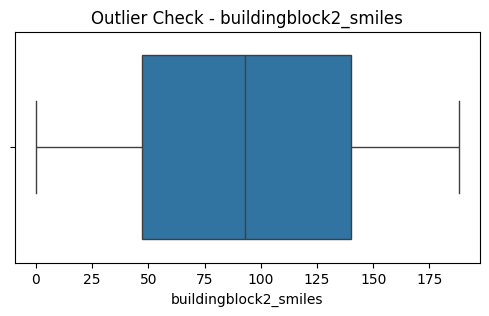

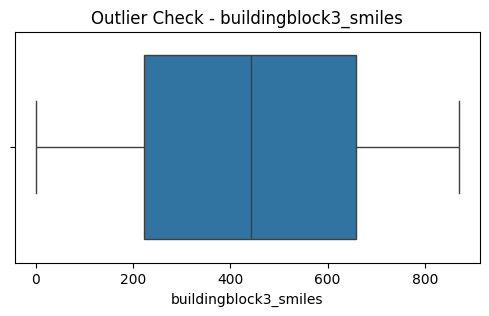

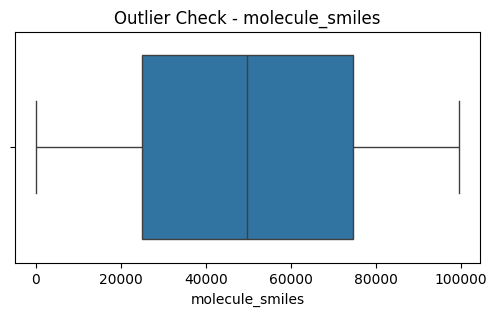

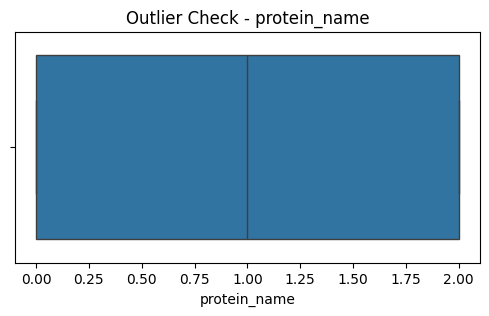

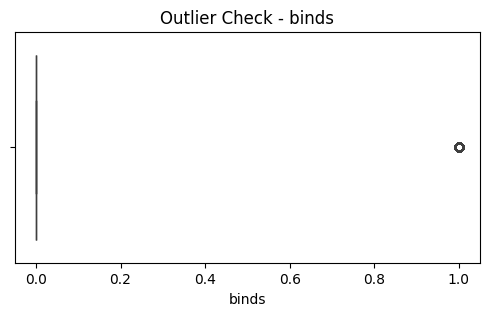

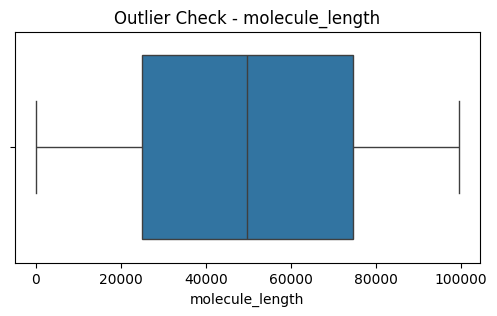

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check - {col}")
    plt.show()


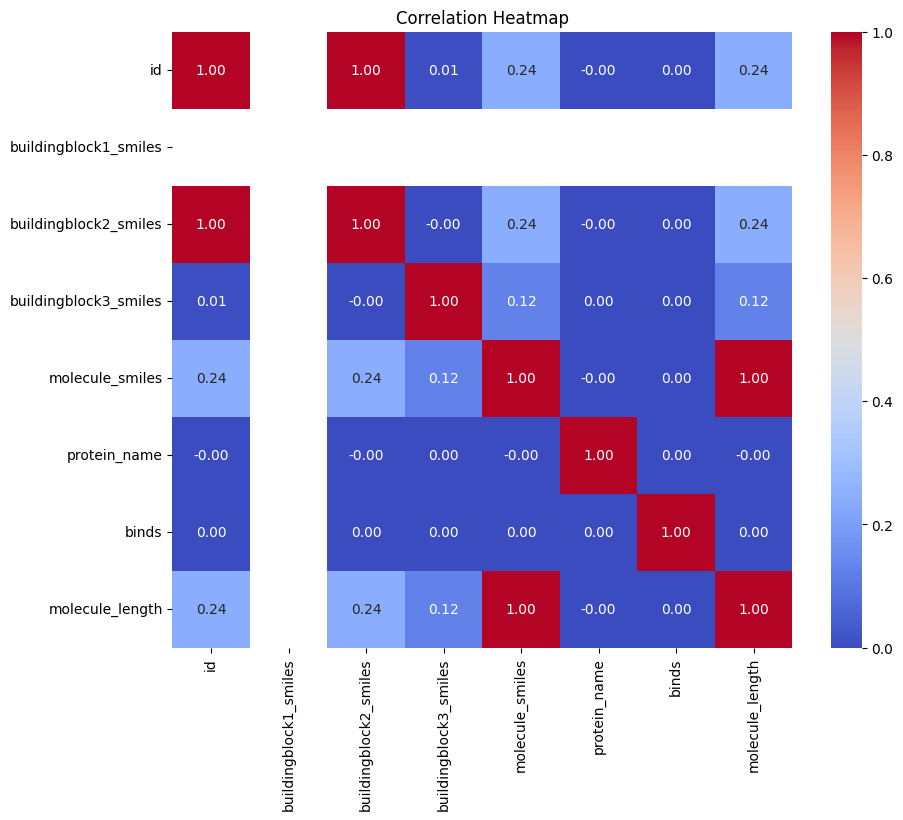

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
# Drop target & ID from features
X = df.drop(['binds', 'id','molecule_length'], axis=1)

# Target is binds
y = df['binds']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train on the full dataset
model.fit(X, y)



RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X)
y_proba = model.predict_proba(X)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Accuracy
print("Accuracy:", accuracy_score(y, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y, y_pred))

# ROC-AUC (binary case)
print("\nROC-AUC Score:", roc_auc_score(y, y_proba[:, 1]))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    297618
           1       1.00      1.00      1.00       645

    accuracy                           1.00    298263
   macro avg       1.00      1.00      1.00    298263
weighted avg       1.00      1.00      1.00    298263


ROC-AUC Score: 1.0


Testing on the test data

In [ ]:
import pandas as pd
import scipy.sparse as sp

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


In [ ]:
test=pd.read_csv('test.csv')

In [ ]:
test.columns

Index(['id', 'buildingblock1_smiles', 'buildingblock2_smiles',
       'buildingblock3_smiles', 'molecule_smiles', 'protein_name'],
      dtype='object')

In [ ]:
test.columns

Index(['id', 'buildingblock1_smiles', 'buildingblock2_smiles',
       'buildingblock3_smiles', 'molecule_smiles', 'protein_name'],
      dtype='object')

In [ ]:
num_cols = test.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = test.select_dtypes(exclude=[np.number]).columns.tolist()
print("\n📊 Numerical Columns:", num_cols)
print("🔤 Categorical Columns:", cat_cols)


📊 Numerical Columns: ['id']
🔤 Categorical Columns: ['buildingblock1_smiles', 'buildingblock2_smiles', 'buildingblock3_smiles', 'molecule_smiles', 'protein_name']


In [ ]:
print("\n NUMERICAL STATS:\n", test[num_cols].describe())
print("\n CATEGORICAL VALUE COUNTS:")
for col in cat_cols:
    print(f"\n{col}:\n", test[col].value_counts())



 NUMERICAL STATS:
                  id
count  1.048575e+06
mean   2.957711e+08
std    3.026977e+05
min    2.952468e+08
25%    2.955090e+08
50%    2.957711e+08
75%    2.960333e+08
max    2.962954e+08

 CATEGORICAL VALUE COUNTS:

buildingblock1_smiles:
 buildingblock1_smiles
O=C(N[C@@H]1CCN(c2cc(C(=O)O)cc(Cl)n2)C1)OCC1c2ccccc2-c2ccccc21    14098
O=C(NC1CN(c2cc(C(=O)O)cc(Cl)n2)C1)OCC1c2ccccc2-c2ccccc21          14064
CC(C)(C)OC(=O)N1CCC(C(=O)O)(c2cccc(Br)c2)CC1                      14041
CC(C)(C)OC(=O)N1C[C@H](Oc2ccccc2I)C[C@@H]1C(=O)O                  13998
CC(C)(C)OC(=O)N1C[C@@H](n2cncc2Br)C[C@H]1C(=O)O                   13996
                                                                  ...  
O=C(NC1(C(=O)O)Cc2ccccc2C1)OCC1c2ccccc2-c2ccccc21                  1989
O=C(N[C@H](Cc1c[nH]c2cc(Cl)ccc12)C(=O)O)OCC1c2ccccc2-c2ccccc21     1989
O=C(Nc1cc(C(=O)O)ccc1F)OCC1c2ccccc2-c2ccccc21                      1989
O=C(Nc1cc(C(F)(F)F)ccc1C(=O)O)OCC1c2ccccc2-c2ccccc21               1989
O=C(N

In [ ]:
label_encoders = {}
for col in test.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])
    label_encoders[col] = le

In [ ]:
test.head()

,id,buildingblock1_smiles,buildingblock2_smiles,buildingblock3_smiles,molecule_smiles,protein_name
0,295246830,0,17,17,565,0
1,295246831,0,17,17,565,1
2,295246832,0,17,17,565,2
3,295246833,0,17,87,574,0
4,295246834,0,17,87,574,1


In [ ]:
X_test = test.drop(['id'], axis=1)

# Predict probabilities for binding = 1
y_proba = model.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
submission = pd.DataFrame({
    'id': test['id'],
    'binds': y_proba[:, 1]
})

In [ ]:
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv created!")
import pandas as pd

submission = pd.read_csv('submission.csv')
print(submission.head(100))


✅ submission.csv created!
           id  binds
0   295246830  0.125
1   295246831  0.390
2   295246832  0.390
3   295246833  0.125
4   295246834  0.390
..        ...    ...
95  295246925  0.390
96  295246926  0.125
97  295246927  0.390
98  295246928  0.390
99  295246929  0.125

[100 rows x 2 columns]


In [ ]:
from google.colab import files
files.download('submission.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>